<a href="https://colab.research.google.com/github/neelmulayPenn/U-Net-Semantic-Segmentation/blob/main/U_Net_NeelMulay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# 0. SETUP
# ================================================================

!nvidia-smi
!pip install torch torchvision albumentations opencv-python matplotlib torchmetrics

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchmetrics import JaccardIndex

import jax
import jax.numpy as jnpg

from flax.training import train_state
import optax
import numpy as np
from tqdm import tqdm

import os
import cv2
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2



/bin/bash: line 1: nvidia-smi: command not found
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 50.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
!pip install cityscapesscripts


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.6/473.6 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.1 MB/s eta 0:00:00
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=6164ca3295c6007c27139c94e3fee30c24996d789fdf60463528c6da66af66d2
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built typing


In [ ]:
from cityscapesscripts.helpers.labels import labels

In [ ]:
CITYSCAPES_COLORS = np.array([
    [128, 64,128], [244, 35,232], [ 70, 70, 70], [102,102,156],
    [190,153,153], [153,153,153], [250,170, 30], [220,220,  0],
    [107,142, 35], [152,251,152], [ 70,130,180], [220, 20, 60],
    [255,  0,  0], [  0,  0,142], [  0,  0, 70], [  0, 60,100],
    [  0, 80,100], [  0,  0,230], [119, 11, 32]
])

def colorize_mask(mask):
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    for i in range(len(CITYSCAPES_COLORS)):
        out[mask == i] = CITYSCAPES_COLORS[i]
    return out

In [ ]:
def build_cityscapes_mapping():
    id_to_trainid = {}
    valid_train_ids = set()

    for lbl in labels:
        if lbl.ignoreInEval:
            id_to_trainid[lbl.id] = 255   # ignore
        else:
            id_to_trainid[lbl.id] = lbl.trainId
            valid_train_ids.add(lbl.trainId)

    num_classes = max(valid_train_ids) + 1
    return id_to_trainid, num_classes


In [ ]:
# Cityscapes ID → trainId mapping (official)
id_to_trainid = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0,    # road
    8: 1,    # sidewalk
    9: 255,
    10: 255,
    11: 2,   # building
    12: 3,   # wall
    13: 4,   # fence
    14: 255,
    15: 255,
    16: 255,
    17: 5,   # pole
    18: 255,
    19: 6,   # traffic light
    20: 7,   # traffic sign
    21: 8,   # vegetation
    22: 9,   # terrain
    23: 10,  # sky
    24: 11,  # person
    25: 12,  # rider
    26: 13,  # car
    27: 14,  # truck
    28: 15,  # bus
    29: 255,
    30: 255,
    31: 16,  # train
    32: 17,  # motorcycle
    33: 18   # bicycle
}

id_to_trainid, NUM_CLASSES = build_cityscapes_mapping()
print("Number of classes:", NUM_CLASSES)


Number of classes: 19


In [ ]:
def remap_cityscapes_mask(mask_np):
    remapped = np.full(mask_np.shape, 255, dtype=np.uint8)

    for k, v in id_to_trainid.items():
        remapped[mask_np == k] = v

    return remapped

/tmp/ipython-input-344577880.py:21: UserWarning: Argument(s) 'var_limit, mean' are not valid for transform GaussNoise
  A.GaussNoise(


Train size: 2975
Val size: 500
Image: torch.Size([3, 256, 512])
Mask:  torch.Size([256, 512])


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


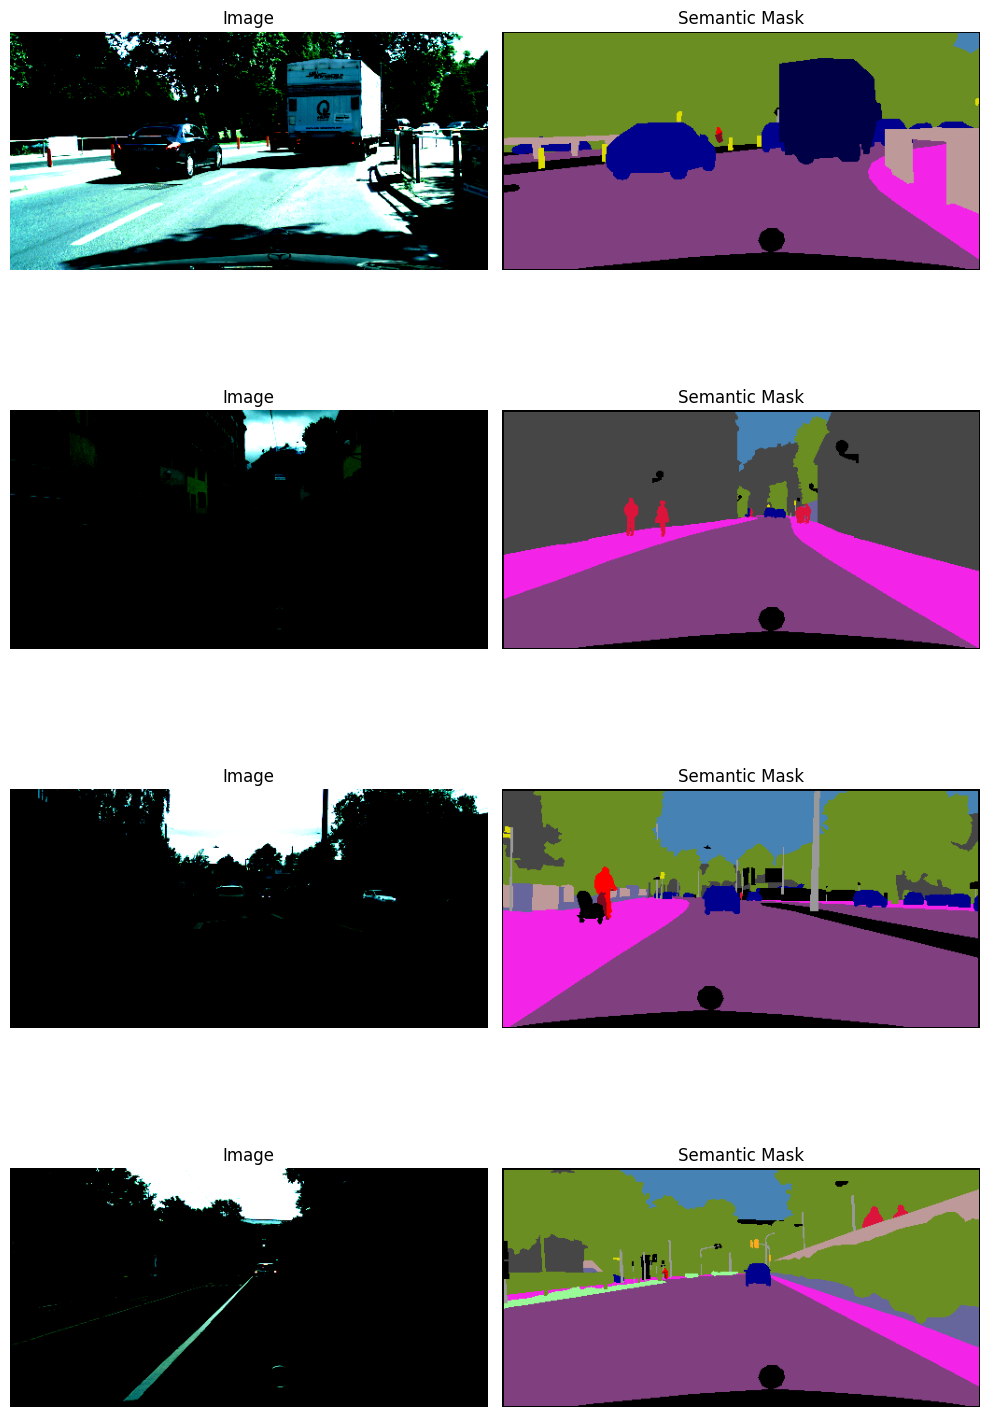

In [ ]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import Cityscapes

import albumentations as A
from albumentations.pytorch import ToTensorV2
from flax import linen as nn

# -----------------------
# 1. Define joint transform
# -----------------------
train_transform = A.Compose([
    # --- Geometry ---
    A.Resize(256, 512),
    A.HorizontalFlip(p=0.5),

    # --- Photometric noise ---
    A.GaussNoise(
        var_limit=(2.0, 8.0),   # ⬅️ much smaller
        mean=0,
        p=0.15
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.1,   # ⬅️ reduced
        contrast_limit=0.1,
        p=0.2
    ),

    # --- Normalize LAST ---
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# -----------------------
# 2. Wrapper dataset so Albumentations can work with torchvision
# -----------------------
class CityscapesDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, transform):
        self.dataset = Cityscapes(
            root=root,
            split=split,
            mode="fine",
            target_type="semantic"
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]  # PIL images

        img_np = np.array(img)
        mask_np = np.array(mask)  # shape (H, W) with class indices
        mask_np = remap_cityscapes_mask(mask_np)

        transformed = self.transform(image=img_np, mask=mask_np)

        # Move to GPU
        img_t = transformed["image"]
        mask_t = transformed["mask"]

        return img_t, mask_t

# -----------------------
# 3. Create Datasets
# -----------------------
ROOT = "/content/drive/MyDrive/MEAM_5310/Cityscapes"    # adjust if needed

train_dataset = CityscapesDataset(ROOT, split="train", transform=train_transform)
val_dataset   = CityscapesDataset(ROOT, split="val",   transform=val_transform)

# -----------------------
# 4. DataLoaders
# -----------------------
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

# -----------------------
# 5. Test one sample
# -----------------------
sample_img, sample_mask = train_dataset[0]
print("Image:", sample_img.shape)
print("Mask: ", sample_mask.shape)

images, masks = next(iter(train_loader))

fig, axs = plt.subplots(4, 2, figsize=(10, 16))

for i in range(4):
    axs[i, 0].imshow(images[i].permute(1, 2, 0).cpu())
    axs[i, 0].set_title("Image")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(colorize_mask(masks[i].cpu().numpy()))
    axs[i, 1].set_title("Semantic Mask")
    axs[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =============================================================
# ConvBlock: 2x Conv + GroupNorm + ReLU + Dropout
# =============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, groups=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.gn2 = nn.GroupNorm(groups, out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = self.conv1(x)
        x = self.gn1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.gn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        return x

# =============================================================
# Encoder: series of ConvBlocks + max pooling
# =============================================================
class Encoder(nn.Module):
    def __init__(self, in_channels, channels):
        super().__init__()
        self.blocks = nn.ModuleList()
        prev_ch = in_channels
        for ch in channels:
            self.blocks.append(ConvBlock(prev_ch, ch))
            prev_ch = ch
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        features = []
        for block in self.blocks:
            x = block(x)
            features.append(x)
            x = self.pool(x)
        return features

# =============================================================
# Decoder: upsample + concat skip + ConvBlock
# =============================================================
class Decoder(nn.Module):
    def __init__(self, encoder_channels, bottleneck_channels):
        super().__init__()
        self.upconvs = nn.ModuleList()
        self.blocks = nn.ModuleList()

        # reversed encoder features, except bottleneck
        skip_channels = encoder_channels[::-1]  # e.g., [256,128,64]
        in_ch = bottleneck_channels
        for skip_ch in skip_channels:
            out_ch = skip_ch
            self.upconvs.append(nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2))
            self.blocks.append(ConvBlock(in_channels=out_ch + skip_ch, out_channels=out_ch))
            in_ch = out_ch

    def forward(self, x, features):
        for upconv, block, skip in zip(self.upconvs, self.blocks, reversed(features)):
            x = upconv(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode='nearest')
            x = torch.cat([x, skip], dim=1)
            x = block(x)
        return x



# =============================================================
# Segmentation Head
# =============================================================
class SegHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, num_classes, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

# =============================================================
# Full UNet-style model
# =============================================================
class MySegNet(nn.Module):
    def __init__(self, num_classes=19):
        super().__init__()
        self.encoder = Encoder(3, [64, 128, 256])
        self.bottleneck = ConvBlock(256, 512)
        self.decoder = Decoder(encoder_channels=[64, 128, 256], bottleneck_channels=512)
        self.seg_head = SegHead(64, num_classes)

    def forward(self, x):
        enc_features = self.encoder(x)
        x = enc_features[-1]
        x = self.bottleneck(x)

        x = self.decoder(x, enc_features)
        x = self.seg_head(x)
        return x


# =============================================================
# Example usage
# =============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MySegNet(num_classes=19).to(device)

dummy = torch.randn(1, 3, 375, 1242).to(device)  # NCHW
out = model(dummy)

print("Output shape:", out.shape)  # (1, 19, H, W)


Output shape: torch.Size([1, 19, 375, 1242])


In [ ]:
import torch

class_weights = torch.tensor([
    1.0,   # 0 road
    1.2,   # 1 sidewalk
    1.0,   # 2 building
    1.5,   # 3 wall
    1.5,   # 4 fence
    2.0,   # 5 pole
    2.0,   # 6 traffic light
    2.0,   # 7 traffic sign
    1.2,   # 8 vegetation
    1.2,   # 9 terrain
    1.0,   # 10 sky
    1.5,   # 11 person
    1.5,   # 12 rider
    1.0,   # 13 car
    1.3,   # 14 truck
    1.3,   # 15 bus
    1.3,   # 16 train
    1.5,   # 17 motorcycle
    1.5    # 18 bicycle
]).to(device)


In [ ]:
def pixel_accuracy(logits, labels, ignore_index=255):
    preds = torch.argmax(logits, dim=1)
    mask = labels != ignore_index
    correct = (preds == labels) & mask
    return correct.sum() / mask.sum()


In [ ]:
import torch

def mean_iou(logits, labels, num_classes):
    """
    logits: (B, H, W, C)
    labels: (B, H, W)
    """
    preds = logits.argmax(-1)  # (B, H, W)
    ious = []

    for c in range(num_classes):
        pred_c = preds == c
        label_c = labels == c

        intersection = (pred_c & label_c).sum().float()
        union = (pred_c | label_c).sum().float()

        iou = intersection / (union + 1e-6)
        ious.append(iou)

    return torch.stack(ious).mean()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def create_train_state(model, lr_schedule):
    """
    model: a PyTorch nn.Module
    lr_schedule: float or a torch.optim.lr_scheduler
    """
    # Dummy input to initialize weights (if needed)
    dummy = torch.ones((1, 512, 512, 3))  # NHWC
    dummy = dummy.permute(0, 3, 1, 2)  # convert to NCHW for PyTorch

    model(dummy)  # forward pass to initialize (optional in PyTorch)

    # AdamW optimizer with weight decay
    optimizer = optim.AdamW(model.parameters(), lr=lr_schedule, weight_decay=1e-4)

    # In PyTorch, there is no "TrainState" like in Flax/JAX
    # Return model and optimizer together
    return model, optimizer


In [ ]:
import torch
import torch.nn.functional as F

def dice_loss(logits, targets, num_classes, ignore_index=255, eps=1e-6):
    """
    logits: (B, C, H, W)
    targets: (B, H, W)
    """
    targets = targets.long()
    # Remove ignore pixels
    mask = targets != ignore_index
    targets = targets * mask

    # One-hot encode targets
    targets_one_hot = F.one_hot(
        targets.clamp(0, num_classes - 1),
        num_classes=num_classes
    ).permute(0, 3, 1, 2).float()

    # Softmax probabilities
    probs = F.softmax(logits, dim=1)

    # Apply mask
    probs = probs * mask.unsqueeze(1)
    targets_one_hot = targets_one_hot * mask.unsqueeze(1)

    # Dice per class
    intersection = torch.sum(probs * targets_one_hot, dim=(0, 2, 3))
    union = torch.sum(probs + targets_one_hot, dim=(0, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)

    return 1 - dice.mean()


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Suppose you already have class weights
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)

def segmentation_loss(logits, targets, num_classes=19):
    # Compute CrossEntropyLoss
    ce = ce_loss_fn(logits, targets)  # <-- call it to get tensor

    # Compute Dice loss (you should have your dice_loss function returning a tensor)
    dice = dice_loss(logits, targets, num_classes=num_classes, ignore_index=255)

    # Combine
    return dice


In [ ]:
import torch

def train_step(model, optimizer, images, masks):
    """
    model: nn.Module
    optimizer: torch.optim.Optimizer
    images: (B, H, W, C) - NHWC
    masks: (B, H, W)
    """
    model.train()


    images = images.to(device, non_blocking=True)
    #masks  = masks.to(device, non_blocking=True)
    masks  = masks.to(device).long()  # important!


    # Convert images to NCHW for PyTorch
    # Convert NHWC → NCHW only if needed
    if images.ndim == 4 and images.shape[-1] == 3:
        images = images.permute(0, 3, 1, 2).contiguous()

    optimizer.zero_grad()

    # Forward pass
    logits = model(images)  # shape (B, C, H, W) if standard PyTorch

    # Convert logits to NHWC to keep logic same as JAX version
    print(images.device, logits.device)


    # Compute loss
    # loss = F.cross_entropy(
    #     logits,
    #     masks.long(),
    #     ignore_index=255
    # )
    loss = segmentation_loss(
    logits,
    masks,
    num_classes=19
    )

    # Backward pass
    loss.backward()
    optimizer.step()

    # Compute accuracy
    acc = pixel_accuracy(logits, masks)

    return model, optimizer, loss.item(), acc


In [ ]:
import torch

def eval_step(model, images, masks):
    """
    model: nn.Module
    images: (B, H, W, C) - NHWC
    masks: (B, H, W)
    """
    model.eval()
    images = images.to(device)
    masks = masks.to(device).long()

    with torch.no_grad():
        # Convert images to NCHW
        #images = images.permute(0, 3, 1, 2)

        # Forward pass
        logits = model(images)  # (B, C, H, W)

        # Compute loss and accuracy
    #     loss = F.cross_entropy(
    #     logits,
    #     masks.long(),
    #     ignore_index=255
    # )
        loss = segmentation_loss(
            logits,
            masks,
            num_classes=19
        )
        acc = pixel_accuracy(logits, masks)
        # iou = mean_iou(logits, masks, num_classes=12)  # optional

    return loss.item(), acc


In [ ]:
import numpy as np
from tqdm import tqdm
import torch

def train_model(model, optimizer, train_loader, val_loader, num_epochs=20):
    """
    model: nn.Module
    optimizer: torch.optim.Optimizer
    train_loader, val_loader: PyTorch DataLoader
    """
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }

    for epoch in range(num_epochs):
        train_losses, train_accs = [], []

        # ---- TRAINING LOOP ----
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")

        for images, masks in loop:
            model, optimizer, loss, acc = train_step(model, optimizer, images, masks)

            loss_val = loss.item() if isinstance(loss, torch.Tensor) else loss
            acc_val  = acc.item()  if isinstance(acc, torch.Tensor)  else acc

            train_losses.append(loss_val)
            train_accs.append(acc_val)

            loop.set_postfix(
                loss=f"{loss_val:.4f}",
                acc=f"{acc_val:.4f}"
            )
            #break

        # ---- VALIDATION LOOP ----
        val_losses, val_accs = [], []
        model.eval()
        with torch.no_grad():
            for images, masks in val_loader:
                loss, acc = eval_step(model, images, masks)
                val_losses.append(loss.cpu().item() if isinstance(loss, torch.Tensor) else loss)
                val_accs.append(acc.cpu().item() if isinstance(acc, torch.Tensor) else acc)
                #break  # Remove this break to validate on full set
        scheduler.step()

        # ---- Log epoch metrics ----
        train_loss_epoch = np.mean(train_losses)
        train_acc_epoch = np.mean(train_accs)
        val_loss_epoch = np.mean(val_losses)
        val_acc_epoch = np.mean(val_accs)

        history["train_loss"].append(train_loss_epoch)
        history["train_acc"].append(train_acc_epoch)
        history["val_loss"].append(val_loss_epoch)
        history["val_acc"].append(val_acc_epoch)

        # print(
        #     f"Epoch {epoch+1}/{num_epochs} | "
        #     f"Train Loss: {train_loss_epoch:.4f} | Train Acc: {train_acc_epoch:.4f} | "
        #     f"Val Loss: {val_loss_epoch:.4f} | Val Acc: {val_acc_epoch:.4f}"
        # )


    return model, history


In [ ]:
def visualize_prediction(state, image, mask):
    import matplotlib.pyplot as plt
    import numpy as np
    import jax.numpy as jnp

    img = image.permute(1,2,0).numpy()
    mask_np = mask.numpy()

    img_jax = torch.array(img[None, ...])
    logits = state.apply_fn(state.params, img_jax)
    pred = np.array(logits.argmax(-1)[0])

    gt_color = decode_cityscapes(mask_np)
    pred_color = decode_cityscapes(pred)

    plt.figure(figsize=(18,5))

    plt.subplot(1,3,1)
    plt.title("Input Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Ground Truth (Cityscapes Colors)")
    plt.imshow(gt_color)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Prediction (Cityscapes Colors)")
    plt.imshow(pred_color)
    plt.axis("off")

    plt.show()


In [ ]:
CITYSCAPES_COLORS = np.array([
    (128, 64,128),   # road
    (244, 35,232),   # sidewalk
    ( 70, 70, 70),   # building
    (102,102,156),   # wall
    (190,153,153),   # fence
    (153,153,153),   # pole
    (250,170, 30),   # traffic light
    (220,220,  0),   # traffic sign
    (107,142, 35),   # vegetation
    (152,251,152),   # terrain
    ( 70,130,180),   # sky
    (220, 20, 60),   # person
    (255,  0,  0),   # rider
    (  0,  0,142),   # car
    (  0,  0, 70),   # truck
    (  0, 60,100),   # bus
    (  0, 80,100),   # train
    (  0,  0,230),   # motorcycle
    (119, 11, 32),   # bicycle
], dtype=np.uint8)


In [ ]:
def decode_cityscapes(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id in range(19):
        color_mask[mask == cls_id] = CITYSCAPES_COLORS[cls_id]
    return color_mask

In [ ]:
# ============================================================
# FINAL CALLING CODE — END-TO-END TRAINING PIPELINE WITH TQDM
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt

num_classes = 19
learning_rate = 1e-4
ignore_index = 255
num_epochs = 50

# ------------------------------------------------------------
# 1. Initialize model + optimizer
# ------------------------------------------------------------
model = MySegNet(num_classes=num_classes)
model = model.to(device)

# Use AdamW optimizer
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.95  # multiply LR by 0.95 every step
)
print("Model initialized. Starting training...\n")

# ------------------------------------------------------------
# 2. Train the model
# ------------------------------------------------------------
model, history = train_model(model, optimizer, train_loader, val_loader, num_epochs=num_epochs)

# ------------------------------------------------------------
# 3. Save trained model parameters
# ------------------------------------------------------------
with open("seg_model_params.pkl", "wb") as f:
    pickle.dump(model.state_dict(), f)

print("Saved model parameters → seg_model_params.pkl")

print("\n--- HISTORY AFTER THIS EPOCH ---")
for k, v in history.items():
    print(f"{k}: {v}")
print("--------------------------------\n")

Epoch 50 Training:   6%|▌         | 42/744 [00:11<03:06,  3.76it/s, acc=0.8782, loss=0.5476]

cuda:0 cuda:0


Epoch 50 Training:   6%|▌         | 43/744 [00:12<03:08,  3.73it/s, acc=0.8767, loss=0.4437]

cuda:0 cuda:0


Epoch 50 Training:   6%|▌         | 44/744 [00:12<03:07,  3.73it/s, acc=0.9352, loss=0.4822]

...

cuda:0 cuda:0


Epoch 50 Training: 100%|██████████| 744/744 [03:18<00:00,  4.07it/s, acc=0.8993, loss=0.5032]

cuda:0 cuda:0


Epoch 50 Training: 100%|██████████| 744/744 [03:18<00:00,  3.75it/s, acc=0.8993, loss=0.5032]


Saved model parameters → seg_model_params.pkl

--- HISTORY AFTER THIS EPOCH ---
train_loss: [np.float64(0.8571667996465518), np.float64(0.7724982145973431), np.float64(0.7354539799433882), np.float64(0.7003027350511603), np.float64(0.6744627896496045), np.float64(0.659090313219255), np.float64(0.6442689209054875), np.float64(0.6346712901547391), np.float64(0.624346373382435), np.float64(0.6146945543987776), np.float64(0.6106624939749318), np.float64(0.603555798049896), np.float64(0.597264025640744), np.float64(0.5917626351758998), np.float64(0.5868645014782106), np.float64(0.5809686554856198), np.float64(0.578316698872274), np.float64(0.5734710155795979), np.float64(0.569327686662956), np.float64(0.5667946796904328), np.float64(0.5637881875198375), np.float64(0.5592331472904452), np.float64(0.5539785244612283), np.float64(0.5562311019147596), np.float64(0.5520568479613591), np.float64(0.5481400950461306), np.float64(0.5483510158555482), np.float64(0.5440420408242492), np.float64(0.5428

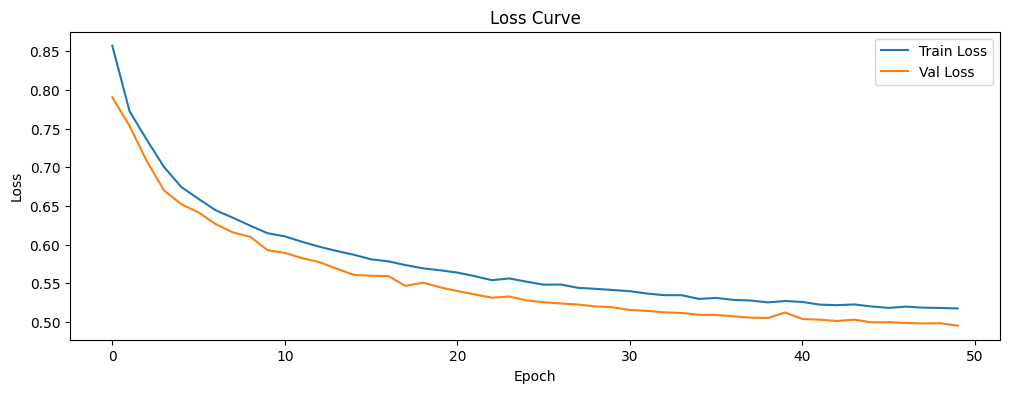

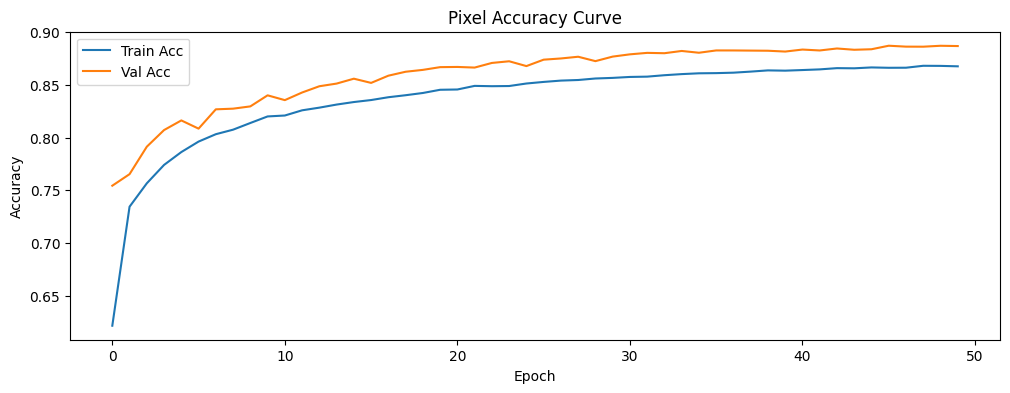

In [ ]:
import matplotlib.pyplot as plt



# ---- Loss ----
plt.figure(figsize=(12,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ---- Accuracy ----
plt.figure(figsize=(12,4))
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Pixel Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

CITYSCAPES_COLORS = np.array([
    [128, 64,128], [244, 35,232], [ 70, 70, 70], [102,102,156],
    [190,153,153], [153,153,153], [250,170, 30], [220,220,  0],
    [107,142, 35], [152,251,152], [ 70,130,180], [220, 20, 60],
    [255,  0,  0], [  0,  0,142], [  0,  0, 70], [  0, 60,100],
    [  0, 80,100], [  0,  0,230], [119, 11, 32]
])

def colorize_mask(mask):
    """Convert (H, W) class indices to RGB colors."""
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    for i, color in enumerate(CITYSCAPES_COLORS):
        out[mask == i] = color
    return out

import matplotlib.pyplot as plt
import torch

def visualize_segmentation(image, gt_mask, pred_mask):
    import matplotlib.pyplot as plt
    import numpy as np

    # ----- IMAGE -----
    image = image.cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])[:, None, None]
    std  = np.array([0.229, 0.224, 0.225])[:, None, None]
    image = image * std + mean
    image = np.clip(image, 0, 1)
    image = np.transpose(image, (1, 2, 0))

    # ----- MASKS -----
    gt_mask = gt_mask.cpu().numpy()
    pred_mask = pred_mask.cpu().numpy()

    gt_color = colorize_mask(gt_mask)
    pred_color = colorize_mask(pred_mask)

    # ----- PLOT -----
    fig, ax = plt.subplots(1, 3, figsize=(18,5))

    ax[0].imshow(image)
    ax[0].set_title("Input Image")
    ax[0].axis("off")

    ax[1].imshow(gt_color)
    ax[1].set_title("Ground Truth (Cityscapes)")
    ax[1].axis("off")

    ax[2].imshow(pred_color)
    ax[2].set_title("Prediction (Cityscapes)")
    ax[2].axis("off")

    plt.show()




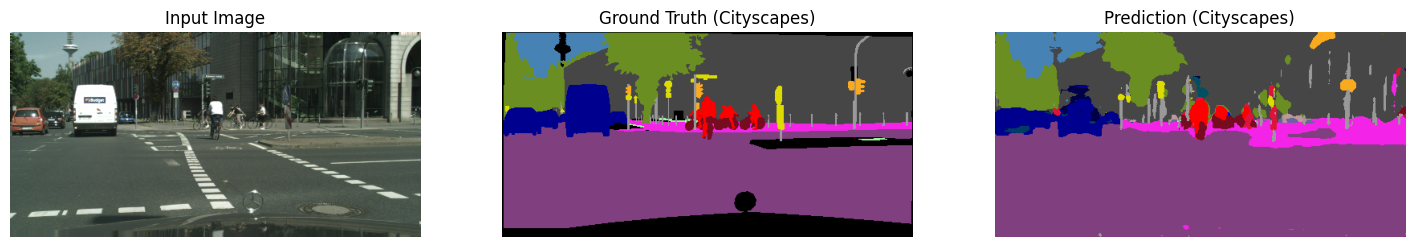

In [ ]:
model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    logits = model(images)
    preds = torch.argmax(logits, dim=1)  # (B,H,W)

# visualize first sample in the batch
visualize_segmentation(images[3], masks[3], preds[3])

In [ ]:
import torch

def compute_iou(pred, target, num_classes):
    """
    pred: (H, W) - predicted class indices
    target: (H, W) - ground truth class indices
    """
    ious = []
    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))  # ignore this class
        else:
            ious.append(intersection / union)
    return ious


In [ ]:
def evaluate_miou(model, loader, num_classes, device="cuda"):
    model.eval()
    iou_list = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)             # NCHW
            masks = masks.to(device)               # HW or NCHW?

            logits = model(images)                 # (B, C, H, W)
            preds = torch.argmax(logits, dim=1)   # (B, H, W)

            for pred, mask in zip(preds, masks):
                iou_per_image = compute_iou(pred, mask, num_classes)
                iou_list.append(iou_per_image)

    # Convert to tensor and compute mean ignoring NaNs
    iou_tensor = torch.tensor(iou_list)
    mean_iou = torch.nanmean(iou_tensor)
    return mean_iou.item()


In [ ]:
num_classes = 19
miou = evaluate_miou(model, val_loader, num_classes, device=device)
print("Validation mIoU:", miou)


Validation mIoU: 0.3291485905647278


In [ ]:
import torch

def update_confusion_matrix(confmat, preds, targets, num_classes, ignore_index=255):
    """
    confmat: (C, C) tensor on CPU
    preds:   (B, H, W) predicted labels
    targets: (B, H, W) ground truth labels
    """
    preds = preds.view(-1)
    targets = targets.view(-1)

    mask = targets != ignore_index
    preds = preds[mask]
    targets = targets[mask]

    indices = targets * num_classes + preds
    conf = torch.bincount(
        indices,
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes)

    confmat += conf.cpu()


In [ ]:
num_classes = 19
confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64)

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        update_confusion_matrix(confmat, preds, masks, num_classes)


In [ ]:
def per_class_iou(confmat):
    TP = torch.diag(confmat)
    FP = confmat.sum(dim=0) - TP
    FN = confmat.sum(dim=1) - TP

    iou = TP / (TP + FP + FN + 1e-6)
    return iou


In [ ]:
ious = per_class_iou(confmat)

for i, val in enumerate(ious):
    print(f"Class {i:02d} IoU: {val:.4f}")


Class 00 IoU: 0.9303
Class 01 IoU: 0.5585
Class 02 IoU: 0.7895
Class 03 IoU: 0.1888
Class 04 IoU: 0.1541
Class 05 IoU: 0.2738
Class 06 IoU: 0.2320
Class 07 IoU: 0.4575
Class 08 IoU: 0.8519
Class 09 IoU: 0.3354
Class 10 IoU: 0.8904
Class 11 IoU: 0.5353
Class 12 IoU: 0.1692
Class 13 IoU: 0.8135
Class 14 IoU: 0.0000
Class 15 IoU: 0.0000
Class 16 IoU: 0.0000
Class 17 IoU: 0.0000
Class 18 IoU: 0.0000


/tmp/ipython-input-3202661017.py:5: RuntimeWarning: invalid value encountered in divide
  confmat_norm = confmat_np / confmat_np.sum(axis=1, keepdims=True)


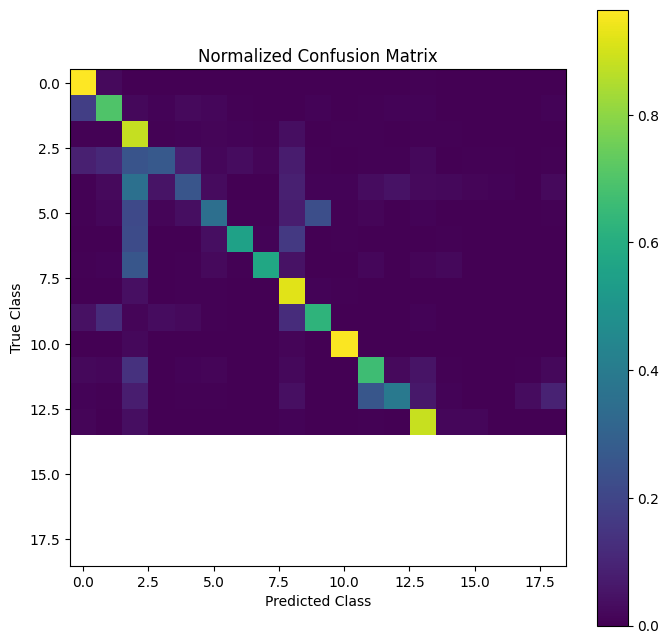

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

confmat_np = confmat.numpy()
confmat_norm = confmat_np / confmat_np.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,8))
plt.imshow(confmat_norm, cmap="viridis")
plt.colorbar()
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")
plt.show()
